#### DRW - Crypto Market Prediction

Develop a model capable of predicting crypto future price movements.

Link to the competition: https://www.kaggle.com/competitions/drw-crypto-market-prediction/overview

The evaluation metric is: Pearson correlation coefficient (PCC)

In [1]:
import numpy as np
import pandas as pd
from pathlib import Path
from autogluon.tabular import TabularPredictor

import plotly.express as px

In [2]:
data_path = "/home/yang/team_kaggle/drw/data"

In [3]:
training_data = pd.read_parquet(Path(data_path, "train.parquet"))
# Shuffle the training set
training_data = training_data.sample(frac=1.0, random_state=42)
training_data.head(10)

,bid_qty,ask_qty,buy_qty,sell_qty,volume,X1,X2,X3,X4,X5,...,X882,X883,X884,X885,X886,X887,X888,X889,X890,label
timestamp,,,,,,,,,,,,,,,,,,,,,
2024-01-13 23:56:00,2.461,16.729,16.000,9.660,25.660,0.318683,-0.442054,-0.314139,-0.009174,0.155676,...,1.267849,1.803564,1.583205,1.583205,1.583205,1.583201,1.562144,1.403082,2.124343,-0.310895
2023-08-10 04:57:00,11.402,24.128,21.453,34.240,55.693,0.778253,0.599912,0.899280,1.205153,0.816274,...,2.210454,2.436272,0.000465,0.000710,0.001704,0.020129,0.078291,0.084454,0.249541,-0.088519
2023-08-09 03:43:00,31.586,18.205,9.702,52.597,62.299,0.884200,0.238718,0.264461,0.365591,0.352049,...,3.297178,2.870151,0.000437,0.000615,0.004109,0.036761,0.096331,0.107545,0.435695,0.517793
2024-01-30 12:24:00,2.274,1.894,2025.472,851.226,2876.698,-1.188960,-0.800285,-1.370735,-1.628248,-0.860071,...,1.638087,1.684898,0.001075,0.000593,0.000447,0.001491,0.030915,0.112137,0.659178,-3.341921
2023-03-24 18:07:00,0.038,3.038,314.488,207.362,521.850,0.258775,0.472250,0.100022,0.089380,0.080815,...,1.972910,1.938618,0.000145,0.000153,0.000139,0.000184,0.008997,0.027900,0.109776,0.708795
2023-10-09 19:51:00,8.227,23.430,54.899,52.840,107.739,-0.213401,-0.594635,-0.654140,-0.433183,-0.123697,...,2.583847,2.117486,0.000026,0.000037,0.000053,0.000107,0.041877,0.252703,1.115018,-0.197125
2023-06-20 07:15:00,12.118,9.710,116.307,64.412,180.719,-0.342781,0.178767,0.142569,-0.102953,-0.165116,...,2.229940,2.023788,0.000280,0.000598,0.000972,0.014617,0.186065,0.324602,1.023193,-0.079308
2024-02-10 11:00:00,11.653,0.774,101.742,180.946,282.688,1.971608,0.598797,1.422187,1.953537,1.244793,...,2.098552,2.451378,1.583407,1.583407,1.583403,1.580962,1.402145,1.054720,1.381461,1.617542
2023-05-02 14:10:00,6.715,1.809,214.752,176.330,391.082,-0.008739,-0.720439,-0.385184,-0.114242,0.063271,...,1.528259,1.655177,0.000052,0.000111,0.000186,0.000462,0.018897,0.088394,0.586482,3.726032


In [4]:
training_split = int(len(training_data) * 0.9)

In [5]:
#train_feature_list = training_data.columns[:-2]  # Exclude 'label' and 'timestamp'

train_feature_list = [
    "X863", "X856", "X344", "X598", "X862", "X385", "X852", "X603", "X860", "X674",
    "X415", "X345", "X137", "X855", "X174", "X302", "X178", "X532", "X168", "X612",
    "bid_qty", "ask_qty", "buy_qty", "sell_qty", "volume"
]

In [6]:
selected_data = training_data[train_feature_list+ ["label"]]
selected_data.head()

,X863,X856,X344,X598,X862,X385,X852,X603,X860,X674,...,X178,X532,X168,X612,bid_qty,ask_qty,buy_qty,sell_qty,volume,label
timestamp,,,,,,,,,,,,,,,,,,,,,
2024-01-13 23:56:00,0.559846,-0.585413,0.206385,0.009490,-1.544661,0.308784,-0.040820,-0.532930,-0.373655,0.396499,...,-0.270145,0.021836,0.016977,0.274790,2.461,16.729,16.000,9.660,25.660,-0.310895
2023-08-10 04:57:00,-0.596573,-0.333420,0.124249,-0.068433,-0.584558,-0.035096,0.530036,-0.546097,0.352261,-0.083225,...,0.562787,0.110142,-0.009486,0.048755,11.402,24.128,21.453,34.240,55.693,-0.088519
2023-08-09 03:43:00,0.505662,0.144063,1.323555,0.152472,-0.091745,0.929243,0.804713,0.070738,1.392628,0.045577,...,0.346442,-0.488627,0.119091,0.720896,31.586,18.205,9.702,52.597,62.299,0.517793
2024-01-30 12:24:00,-0.176571,0.314866,0.778438,2.000000,-0.340439,0.089123,1.395871,1.017423,-0.260132,0.966820,...,0.130632,-0.118036,0.130537,1.293954,2.274,1.894,2025.472,851.226,2876.698,-3.341921
2023-03-24 18:07:00,-0.401126,0.125617,0.401346,-0.025703,0.207477,-0.243294,0.708550,0.387844,0.288003,0.099227,...,-0.533054,0.546898,0.098577,0.185636,0.038,3.038,314.488,207.362,521.850,0.708795


In [ ]:
# Hyperparameters for the TabularPredictor
time_limit = 10 * 60  # train various models for ~2 min
num_trials = 5  # try at most 5 different hyperparameter configurations for each type of model
search_strategy = 'auto'  # to tune hyperparameters using random search routine with a local scheduler


# hyperparameter_tune_kwargs = {  # HPO is not performed unless hyperparameter_tune_kwargs is specified
#     'num_trials': num_trials,
#     'scheduler' : 'local',
#     'searcher': search_strategy,
# }

In [ ]:
predictor = TabularPredictor(label="label").fit(
    training_data[train_feature_list+ ["label"]][:training_split],
    time_limit=time_limit,
    num_bag_folds=5, num_bag_sets=1, num_stack_levels=1,
    # hyperparameters=hyperparameters,
    # hyperparameter_tune_kwargs=hyperparameter_tune_kwargs,
)

No path specified. Models will be saved in: "AutogluonModels/ag-20250615_163343"
Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.3.1
Python Version:     3.12.10
Operating System:   Linux
Platform Machine:   x86_64
Platform Version:   #1 SMP PREEMPT_DYNAMIC Mon Apr 21 17:08:54 UTC 2025
CPU Count:          16
Memory Avail:       16.97 GB / 27.41 GB (61.9%)
Disk Space Avail:   693.45 GB / 1006.85 GB (68.9%)
No presets specified! To achieve strong results with AutoGluon, it is recommended to use the available presets. Defaulting to `'medium'`...
	Recommended Presets (For more details refer to https://auto.gluon.ai/stable/tutorials/tabular/tabular-essentials.html#presets):
	presets='experimental' : New in v1.2: Pre-trained foundation model + parallel fits. The absolute best accuracy without consideration for inference speed. Does not support GPU.
	presets='best'         : Maximize accuracy. Recommended for most users. Use in competit

[1000]	valid_set's rmse: 0.59349
[2000]	valid_set's rmse: 0.482426
[3000]	valid_set's rmse: 0.415878
[4000]	valid_set's rmse: 0.371073
[5000]	valid_set's rmse: 0.339585
[6000]	valid_set's rmse: 0.314894
[7000]	valid_set's rmse: 0.295491
[8000]	valid_set's rmse: 0.280532
[9000]	valid_set's rmse: 0.267651
[10000]	valid_set's rmse: 0.257173


	-0.2572	 = Validation score   (-root_mean_squared_error)
	48.99s	 = Training   runtime
	0.43s	 = Validation runtime
Fitting model: LightGBM ... Training model for up to 422.57s of the 422.57s of remaining time.


[1000]	valid_set's rmse: 0.491198
[2000]	valid_set's rmse: 0.374419
[3000]	valid_set's rmse: 0.314459
[4000]	valid_set's rmse: 0.278392
[5000]	valid_set's rmse: 0.254019
[6000]	valid_set's rmse: 0.236359
[7000]	valid_set's rmse: 0.222809
[8000]	valid_set's rmse: 0.212699
[9000]	valid_set's rmse: 0.204258
[10000]	valid_set's rmse: 0.197274


	-0.1973	 = Validation score   (-root_mean_squared_error)
	50.43s	 = Training   runtime
	0.39s	 = Validation runtime
Fitting model: RandomForestMSE ... Training model for up to 371.47s of the 371.47s of remaining time.
	-0.2143	 = Validation score   (-root_mean_squared_error)
	163.91s	 = Training   runtime
	0.03s	 = Validation runtime
Fitting model: CatBoost ... Training model for up to 207.39s of the 207.38s of remaining time.
	-0.2798	 = Validation score   (-root_mean_squared_error)
	180.76s	 = Training   runtime
	0.01s	 = Validation runtime
Fitting model: ExtraTreesMSE ... Training model for up to 26.57s of the 26.57s of remaining time.
	-0.2384	 = Validation score   (-root_mean_squared_error)
	17.52s	 = Training   runtime
	0.03s	 = Validation runtime
Fitting model: NeuralNetFastAI ... Training model for up to 8.88s of the 8.88s of remaining time.
	Ran out of time, stopping training early. (Stopping on epoch 0)
	-0.726	 = Validation score   (-root_mean_squared_error)
	10.0s	 = Train

In [9]:
predictor.evaluate(training_data[train_feature_list+ ["label"]][training_split:])

{'root_mean_squared_error': np.float64(-0.1925196169917191),
 'mean_squared_error': -0.03706380292663822,
 'mean_absolute_error': -0.13221234495762235,
 'r2': 0.9626595933228641,
 'pearsonr': 0.9828316215405176,
 'median_absolute_error': np.float64(-0.0968436134097902)}

In [10]:
predictor.feature_importance(training_data[train_feature_list+ ["label"]][training_split:])

Computing feature importance via permutation shuffling for 25 features using 5000 rows with 5 shuffle sets...
	92.78s	= Expected runtime (18.56s per shuffle set)
	58.65s	= Actual runtime (Completed 5 of 5 shuffle sets)


,importance,stddev,p_value,n,p99_high,p99_low
X862,0.394693,0.005907,6.019846e-09,5,0.406856,0.382529
X345,0.293689,0.016335,1.143730e-06,5,0.327323,0.260055
X860,0.283846,0.011601,3.341218e-07,5,0.307733,0.259959
X385,0.264863,0.014390,1.041402e-06,5,0.294492,0.235234
X344,0.264542,0.007922,9.637278e-08,5,0.280852,0.248231
X532,0.241108,0.011800,6.863463e-07,5,0.265405,0.216810
X137,0.235219,0.005873,4.659108e-08,5,0.247311,0.223126
X852,0.234471,0.028268,2.486624e-05,5,0.292674,0.176268
X302,0.234392,0.011918,7.993355e-07,5,0.258931,0.209852
X178,0.179761,0.008729,6.652258e-07,5,0.197735,0.161787


In [11]:
predictor.leaderboard(training_data[train_feature_list+ ["label"]][training_split:])

,model,score_test,score_val,eval_metric,pred_time_test,pred_time_val,fit_time,pred_time_test_marginal,pred_time_val_marginal,fit_time_marginal,stack_level,can_infer,fit_order
0,WeightedEnsemble_L2,-0.192520,-0.187470,root_mean_squared_error,4.631383,0.417813,214.348173,0.001494,0.000398,0.006475,2,True,9
1,LightGBM,-0.198440,-0.197274,root_mean_squared_error,4.461655,0.389819,50.434381,4.461655,0.389819,50.434381,1,True,4
2,RandomForestMSE,-0.225590,-0.214305,root_mean_squared_error,0.168234,0.027595,163.907318,0.168234,0.027595,163.907318,1,True,5
3,ExtraTreesMSE,-0.244043,-0.238445,root_mean_squared_error,0.099226,0.027837,17.520041,0.099226,0.027837,17.520041,1,True,7
4,LightGBMXT,-0.267358,-0.257173,root_mean_squared_error,4.736673,0.426548,48.990092,4.736673,0.426548,48.990092,1,True,3
5,CatBoost,-0.289368,-0.279786,root_mean_squared_error,0.067254,0.009974,180.759732,0.067254,0.009974,180.759732,1,True,6
6,NeuralNetFastAI,-0.735107,-0.725968,root_mean_squared_error,0.242674,0.023926,9.999264,0.242674,0.023926,9.999264,1,True,8
7,KNeighborsUnif,-1.086710,-1.086705,root_mean_squared_error,11.735831,1.307040,2.541097,11.735831,1.307040,2.541097,1,True,1
8,KNeighborsDist,-1.088751,-1.090297,root_mean_squared_error,12.434804,1.207436,0.682774,12.434804,1.207436,0.682774,1,True,2


#### Model evaluation

In [12]:
# load saved model to make predictions
#predictor = TabularPredictor.load('AutoGluonModels/ag-20250615_101641/models')
y_pred = predictor.predict(training_data[train_feature_list][training_split:])
y_pred

timestamp
2023-08-17 23:26:00   -0.502101
2023-08-27 19:07:00   -0.592225
2024-01-25 09:44:00   -0.008279
2023-11-23 01:02:00    0.199809
2023-04-21 21:18:00   -0.009892
                         ...   
2023-05-16 16:20:00   -0.055119
2023-08-28 07:59:00    0.266062
2023-11-10 15:28:00    1.024972
2023-05-31 17:24:00    1.274600
2023-05-24 19:10:00    1.070163
Name: label, Length: 52589, dtype: float32

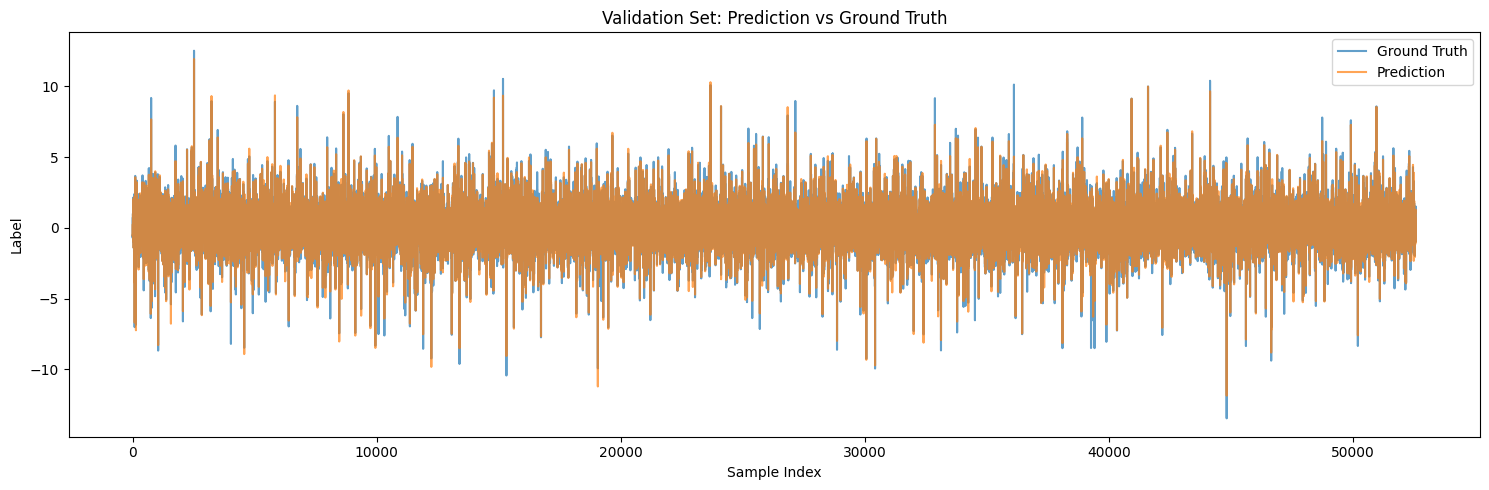

In [13]:
import matplotlib.pyplot as plt

# Get ground truth labels for the validation set
y_true = training_data["label"][training_split:].to_numpy().flatten()

plt.figure(figsize=(15, 5))
plt.plot(y_true, label='Ground Truth', alpha=0.7)
plt.plot(y_pred.values, label='Prediction', alpha=0.7)
plt.title('Validation Set: Prediction vs Ground Truth')
plt.xlabel('Sample Index')
plt.ylabel('Label')
plt.legend()
plt.tight_layout()
plt.show()

In [14]:
from scipy.stats import pearsonr

# Calculate Pearson correlation coefficient
pcc, _ = pearsonr(y_true, y_pred.values)
print("Pearson correlation coefficient (PCC):", pcc)

Pearson correlation coefficient (PCC): 0.9828316215405176


#### Predictions with test data for submission

In [15]:
testing_data = pd.read_parquet(Path(data_path, "test.parquet"))
testing_data = testing_data.drop(columns=["label"])
testing_data.head(10)

,bid_qty,ask_qty,buy_qty,sell_qty,volume,X1,X2,X3,X4,X5,...,X881,X882,X883,X884,X885,X886,X887,X888,X889,X890
ID,,,,,,,,,,,,,,,,,,,,,
1,0.114,12.121,10.587,10.971,21.558,-0.732818,0.512331,-0.041982,-0.598260,-0.517646,...,0.433290,1.014336,1.367567,1.584126,1.584126,1.584126,1.584125,1.567979,1.426368,2.192682
2,2.426,2.962,136.241,12.304,148.545,-0.337995,-0.412176,-0.259468,-0.334809,-0.247443,...,0.725448,1.748939,1.848177,0.000131,0.000323,0.001746,0.007319,0.050925,0.142206,0.739759
3,1.085,2.343,23.390,57.171,80.561,0.111249,0.458221,0.466916,0.574081,0.324722,...,0.743693,1.704680,1.772028,0.000550,0.003597,0.009265,0.019948,0.072535,0.169672,0.807862
4,14.793,1.117,116.518,13.082,129.600,-0.149399,-0.640638,-0.873778,-1.026144,-0.508816,...,0.451041,0.930946,1.037839,1.382037,1.382037,1.382037,1.382037,1.381752,1.363445,2.465509
5,0.033,14.178,43.800,49.836,93.636,-0.694662,0.611254,0.067671,-0.531632,-0.581450,...,0.602724,1.080267,1.141878,0.000363,0.012718,0.137533,0.464112,1.050577,1.268567,2.499015
6,1.904,1.601,27.405,34.369,61.774,-0.081802,0.347083,0.227799,0.213294,0.061112,...,0.610643,1.339334,1.562964,0.000091,0.000092,0.000117,0.001221,0.136653,0.456839,1.499047
7,24.015,0.846,138.360,104.973,243.333,-0.381496,-1.052732,-1.504009,-1.410267,-0.621725,...,1.153612,2.211688,2.166094,0.000052,0.000077,0.000126,0.000379,0.016070,0.044043,0.279279
8,2.074,12.834,33.269,5.475,38.744,-0.037805,-0.060126,-0.089530,-0.186921,-0.147550,...,0.547253,0.984029,1.124451,1.582776,1.582776,1.582776,1.582776,1.581797,1.543977,2.682088
9,1.071,0.037,580.778,839.700,1420.478,1.131547,1.070453,1.403274,1.383598,0.682223,...,1.787331,3.065513,2.480738,0.000058,0.000068,0.000067,0.000090,0.007380,0.054977,0.462377


In [16]:
# predict on the test set
predictions = predictor.predict(testing_data[train_feature_list])

# prepare submission DataFrame
submission_df = pd.DataFrame({
    "ID": np.arange(1, len(predictions)+1),
    "prediction": predictions
})
submission_df.to_csv("submission.csv", index=False)
submission_df

,ID,prediction
ID,,
1,1,-0.211697
2,2,0.953553
3,3,0.260375
4,4,-0.482330
5,5,0.153279
...,...,...
538146,538146,-0.199865
538147,538147,-0.637537
538148,538148,0.053128


In [17]:
sample_submission = pd.read_csv(Path(data_path, "sample_submission.csv"))
sample_submission.head(10)

,ID,prediction
0,1,-0.280233
1,2,1.371969
2,3,-2.045252
3,4,-1.447555
4,5,-1.303901
5,6,1.659284
6,7,1.376758
7,8,0.237542
8,9,-0.101127
9,10,1.267094
